## Unsupervised Analysis of Mice Protein Expression (PCA, KPCA; SVD; K-Means, Kernel K-Means, EM)
## Sunny Chen

Neurodegenerative and control phenotypes can be explored via protein expression profiles measured from mouse brain tissue. This assignment focuses on unsupervised learning clustering and dimensionality reduction using the provided mice-protein.csv dataset. We will:

* Cluster the samples without and with dimensionality reduction (PCA, SVD, KPCA).
* Generate pseudo-labels from clustering, then train a simple Minimum Distance Classifier  using a proper train/test split.
* Visualize clustering results using t-SNE plots for better interpretation.
* Finally, bring back the ground-truth labels (initially ignored) to evaluate how well your unsupervised structure aligns with reality.

Use mice-protein.csv from the Files section. It contains multiple protein expression features per sample and one or more columns indicating class/condition.

* Identify the true label column (e.g., condition/behavior) and set it aside during Tasks 1–3. Keep a copy as y_true for the final comparison.
* Use all remaining numerical feature columns as your D.
* Handle missing values appropriately and standardize features.
* Create initial t-SNE visualization of the raw data colored by true labels (for reference only - don't use this during clustering).

In [427]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import Dict

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, adjusted_rand_score, normalized_mutual_info_score, classification_report
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.optimize import linear_sum_assignment

In [428]:
# Function that uses TSNE for plotting.
def plot_tsne(data, labels, title):
    tsne = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, random_state=42)
    Z = tsne.fit_transform(data)
    plt.figure(figsize=(6, 6))
    plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=16)
    plt.title(title)
    plt.show()

In [429]:
def evaluate_internal(X: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    if len(np.unique(labels)) in (0, 1) or len(np.unique(labels)) == len(labels):
        sil = np.nan
    else:
        sil = silhouette_score(X, labels)
    return {"silhouette": sil}

In [430]:
df = pd.read_csv('mice-protein.csv')
df.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


## 1.1 Data Preparation

In [431]:
# This shows the number of the missing values in each column
missing = df.isnull().sum()
print(missing[missing>0])

DYRK1A_N        3
ITSN1_N         3
BDNF_N          3
NR1_N           3
NR2A_N          3
pAKT_N          3
pBRAF_N         3
pCAMKII_N       3
pCREB_N         3
pELK_N          3
pERK_N          3
pJNK_N          3
PKCA_N          3
pMEK_N          3
pNR1_N          3
pNR2A_N         3
pNR2B_N         3
pPKCAB_N        3
pRSK_N          3
AKT_N           3
BRAF_N          3
CAMKII_N        3
CREB_N          3
ELK_N          18
ERK_N           3
GSK3B_N         3
JNK_N           3
MEK_N           7
TRKA_N          3
RSK_N           3
APP_N           3
Bcatenin_N     18
SOD1_N          3
MTOR_N          3
P38_N           3
pMTOR_N         3
DSCR1_N         3
AMPKA_N         3
NR2B_N          3
pNUMB_N         3
RAPTOR_N        3
TIAM1_N         3
pP70S6_N        3
BAD_N         213
BCL2_N        285
pCFOS_N        75
H3AcK18_N     180
EGR1_N        210
H3MeK4_N      270
dtype: int64


In [432]:
#df=df.fillna(df.mean())
# First, identify numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Fill NA values only in numeric columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# For non-numeric columns, you might want to fill with mode (most frequent value) or another strategy
categorical_columns = df.select_dtypes(exclude=[np.number]).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

In [433]:
# This means taking from index 1 to the end -4
data = df.iloc[:,1:-4]
y_true = df.iloc[:,-1] # Since we chose -1 that is the "class" column of the data

# k is number of clusters/unique classes in the column we chose
k=y_true.nunique()
print("k = Number of classes: ", k)
data.head()

k = Number of classes:  8


,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
0,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.188852,0.122652,0.134762,0.106305,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652
1,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.200404,0.116682,0.134762,0.106592,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610
2,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.193685,0.118508,0.134762,0.108303,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427
3,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.192112,0.132781,0.134762,0.103184,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563
4,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.205604,0.129954,0.134762,0.104784,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730


In [434]:
# This shows the number of the missing values in each column
missing = data.isnull().sum()
print(missing[missing>0])

Series([], dtype: int64)


In [435]:
# Z-score standardization
mu = np.mean(data, axis=0)
sigma = data.std(axis=0, ddof=1)
data = (data - mu) / sigma
print(data.shape)
print("Number of classes (k):", len(np.unique(y_true)))

(1080, 77)
Number of classes (k): 8


## 1.2 K-Means

Seed  0 | silhouette score = 0.1346
Seed  1 | silhouette score = 0.1298
Seed  2 | silhouette score = 0.1337
Seed  3 | silhouette score = 0.1339
Seed  4 | silhouette score = 0.1352
Average silhouette score: 0.1335 ± 0.0019
Best seed: 4 | Best silhouette: 0.1352
Cluster sizes (best run): {0: 15, 1: 147, 2: 75, 3: 226, 4: 160, 5: 134, 6: 113, 7: 210}


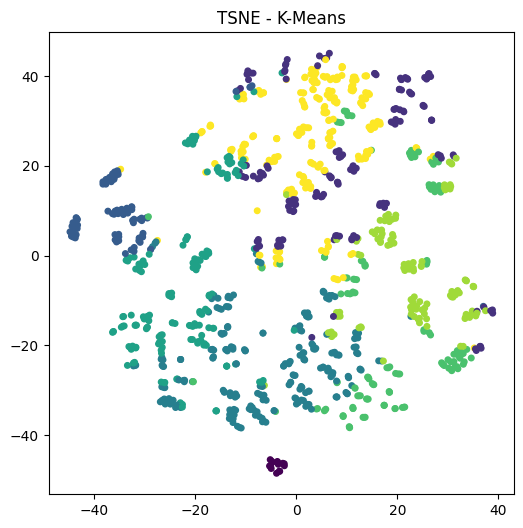

In [436]:
# First compute the labels by clustering using kmeans
seeds = [0, 1, 2, 3, 4]
sil_scores = []
labels_by_seed = []
sizes_by_seed = []

def cluster_size_counts(labels):
    u, c = np.unique(labels, return_counts=True)
    return dict(zip(u.tolist(), c.tolist()))

for seed in seeds:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=seed)
    kmeans.fit(data) 
    label_kmeans = kmeans.predict(data)
    
    # After we compute the labels we then give it a silhouette sore
    sil = silhouette_score(data, label_kmeans)
    sil_scores.append(sil)
    labels_by_seed.append(label_kmeans)
    sizes_by_seed.append(cluster_size_counts(label_kmeans))
    print(f"Seed {seed:>2} | silhouette score = {sil:.4f}")

avg_sil = np.mean(sil_scores)
std_sil = np.std(sil_scores)
best_idx = int(np.argmax(sil_scores))

labels_kmeans = labels_by_seed[best_idx]
best_kmeans_sil = sil_scores[best_idx]

print(f"Average silhouette score: {avg_sil:.4f} ± {std_sil:.4f}")
print(f"Best seed: {seeds[best_idx]} | Best silhouette: {best_kmeans_sil:.4f}")
print(f"Cluster sizes (best run): {sizes_by_seed[best_idx]}")

plot_tsne(data, label_kmeans, title="TSNE - K-Means")

## 1.3 Kernel K-Means

In [437]:
def kernel_kmeans(D, k, kernel='rbf', kernel_param=None, max_iter=200, tol=1e-3, random_state=0, init_labels=None):

    rng = np.random.default_rng(random_state)

    # Build or accept kernel matrix K
    if kernel == 'precomputed':
        K = np.asarray(D, dtype=float)
    else:
        if kernel_param is not None:
            if kernel == 'rbf':
                K = pairwise_kernels(D, metric='rbf', gamma=float(kernel_param))
            elif kernel == 'poly':
                K = pairwise_kernels(D, metric='poly', degree=int(kernel_param))
            elif kernel == 'sigmoid':
                K = pairwise_kernels(D, metric='sigmoid', gamma=float(kernel_param))
            else:
                K = pairwise_kernels(D, metric=kernel)
        else:
            K = pairwise_kernels(D, metric=kernel)

    n = K.shape[0]

    # Init labels
    if init_labels is not None:
        labels = np.asarray(init_labels, dtype=int)
        if labels.shape[0] != n:
            raise ValueError("init_labels must have length equal to number of samples.")
        # Force labels to 0..k-1 if needed
        uniq = np.unique(labels)
        remap = {u: i for i, u in enumerate(uniq)}
        labels = np.array([remap[u] for u in labels])
        if len(np.unique(labels)) > k:
            raise ValueError("init_labels contains more than k unique clusters.")
        # If fewer than k appear, we’ll fix empties in-loop
    else:
        labels = rng.integers(0, k, size=n)

    obj_trace, move_trace = [], []

    for it in range(1, max_iter + 1):
        clusters = [np.where(labels == i)[0] for i in range(k)]
        sizes = np.array([len(idx) for idx in clusters], dtype=float)

        # Handle empty clusters by seeding a random point
        for i, sz in enumerate(sizes):
            if sz == 0:
                j = rng.integers(0, n)
                labels[j] = i
                clusters[i] = np.array([j])
                sizes[i] = 1.0

        # Compute distance-to-centroid in feature space
        sqnorm = np.zeros(k)
        avg_j_i = np.zeros((n, k))
        for c in range(k):
            idx = clusters[c]
            Ki = K[np.ix_(idx, idx)]
            nc = sizes[c]
            sqnorm[c] = Ki.sum() / (nc * nc)
            avg_j_i[:, c] = K[:, idx].sum(axis=1) / nc

        K_diag = np.diag(K)
        dists = sqnorm[None, :] - 2.0 * avg_j_i + K_diag[:, None]

        new_labels = np.argmin(dists, axis=1)
        moved = np.mean(new_labels != labels)
        move_trace.append(moved)
        labels = new_labels
        obj_trace.append(np.sum(dists[np.arange(n), labels]))

        if moved <= tol:
            return labels, it, {"objective": obj_trace, "moved": move_trace}

    return labels, max_iter, {"objective": obj_trace, "moved": move_trace}

def rbf_gamma_median_heuristic(X, subsample=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    if n > subsample:
        idx = rng.choice(n, size=subsample, replace=False)
        X = X[idx]
    sq = np.sum(X**2, axis=1, keepdims=True)
    d2 = sq - 2 * X @ X.T + sq.T
    tri = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(np.sqrt(np.maximum(tri, 0.0)))
    if med <= 0:
        med = 1.0
    return 1.0 / (med**2)

Kernel K-Means gamma=0.001  | iters= 16 | moved_last=0.0009 | silhouette=0.1274
Kernel K-Means gamma=0.01   | iters= 21 | moved_last=0.0009 | silhouette=0.0816
Kernel K-Means gamma=0.1    | iters= 15 | moved_last=0.0009 | silhouette=-0.0834
Kernel K-Means gamma=1      | iters=  1 | moved_last=0.0000 | silhouette=-0.0266
Kernel K-Means gamma=10     | iters=  1 | moved_last=0.0000 | silhouette=-0.0266

Best Kernel K-Means: gamma=0.001 | silhouette=0.1274


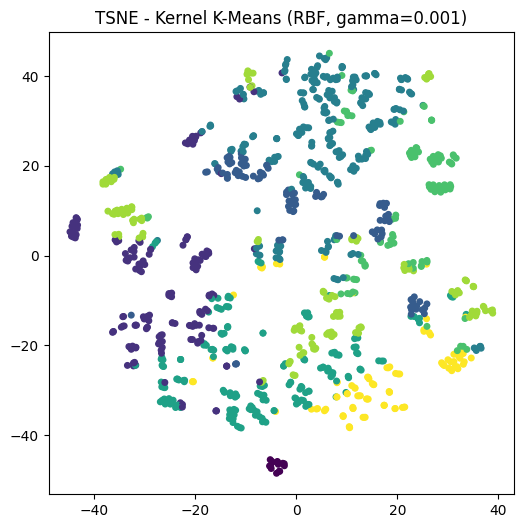

In [438]:
gammas = [1e-3, 1e-2, 1e-1, 1, 10]
best_gamma, best_sil, kkm_labels = None, -np.inf, None

X_arr = np.asarray(data, dtype=float)

for g in gammas:
    labels, iters, info = kernel_kmeans(
        X_arr, k=k, kernel='rbf', kernel_param=g, max_iter=200, tol=1e-3, random_state=42
    )
    s = silhouette_score(X_arr, labels)
    print(f"Kernel K-Means gamma={g:<6} | iters={iters:3d} | moved_last={info['moved'][-1]:.4f} | silhouette={s:.4f}")
    if s > best_sil:
        best_gamma, best_sil, kkm_labels = g, s, labels

print(f"\nBest Kernel K-Means: gamma={best_gamma} | silhouette={best_sil:.4f}")
plot_tsne(X_arr, kkm_labels, title=f"TSNE - Kernel K-Means (RBF, gamma={best_gamma})")

## 1.4 Expectation Maximization

GMM (EM) silhouette: 0.13356045061484098


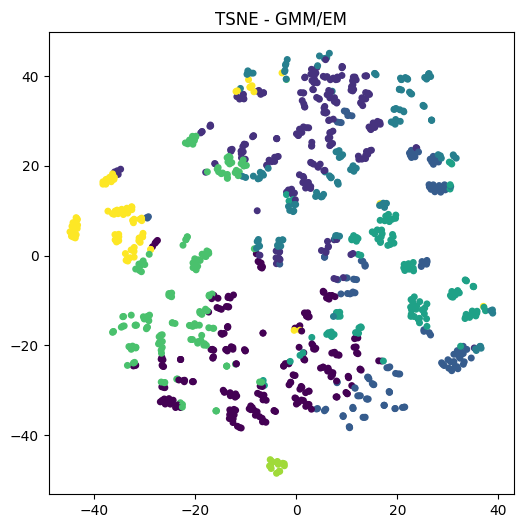

In [439]:
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
label_gmm = gmm.fit_predict(data)
gmm_sil = silhouette_score(data, label_gmm)
print("GMM (EM) silhouette:", gmm_sil)

plot_tsne(data, label_gmm, title="TSNE - GMM/EM")

## 1.5 Agglomerative Hierarchicial Clustering

In [440]:
# Run agglomerative with all 4 linkage criteria
linkages = ["ward", "complete", "average", "single"]
agg_results = {}

for lk in linkages:
    agg = AgglomerativeClustering(n_clusters=k, linkage=lk)

    labels = agg.fit_predict(data)
    
    # compute silhouette if >1 cluster
    sil = silhouette_score(data, labels) if len(np.unique(labels)) > 1 else np.nan

    agg_results[lk] = {"labels": labels, "silhouette": sil}
    print(f"{lk:8s} | silhouette = {sil:.4f}")

# Pick best linkage by silhouette
best_lk = max(agg_results, key=lambda x: agg_results[x]["silhouette"])
print("\nBest linkage by silhouette:", best_lk)

labels_agg_best = agg_results[best_lk]["labels"]

ward     | silhouette = 0.0992
complete | silhouette = 0.0707
average  | silhouette = 0.1758
single   | silhouette = 0.2009

Best linkage by silhouette: single


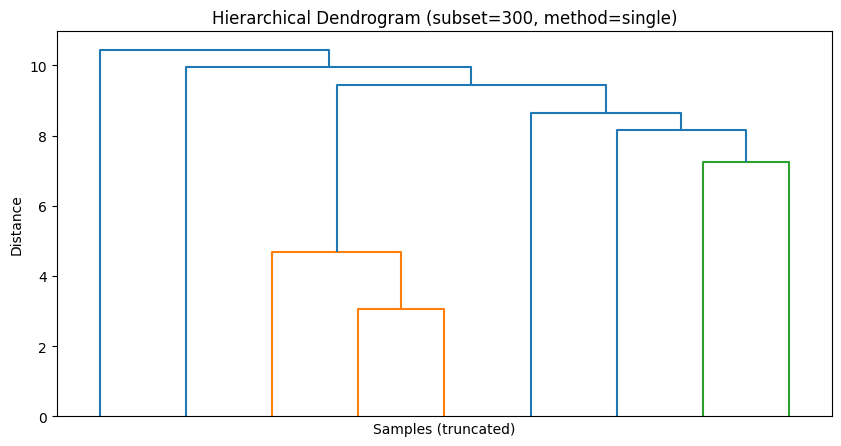

In [441]:
# Subsample for dendrogram
N = min(300, data.shape[0])  # keep first 300
X_for_tree = data[:N]

# Create linkage matrix with SciPy
Z = linkage(X_for_tree, method=best_lk)

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True)
plt.title(f"Hierarchical Dendrogram (subset={N}, method={best_lk})")
plt.xlabel("Samples (truncated)")
plt.ylabel("Distance")
plt.show()

## 1.6 Compare Methods

In [442]:
# Build rows for the comparison table
rows = []

# K-Means
rows.append(["K-Means", avg_sil, cluster_size_counts(labels_kmeans)])

# Kernel K-Means
rows.append([f"Kernel K-Means (gamma={best_gamma})", best_sil, cluster_size_counts(kkm_labels)])

# GMM
rows.append(["GMM", gmm_sil, cluster_size_counts(label_gmm)])

# Agglomerative (all linkages)
for lk, res in agg_results.items():
    rows.append([f"Agglomerative-{lk}", res["silhouette"], cluster_size_counts(res["labels"])])

# Create DataFrame
df_task1 = pd.DataFrame(rows, columns=["Method", "Silhouette", "Cluster sizes"])
display(df_task1)

# Store labels for later reference
cluster_labels_store = {
    "K-Means": labels_kmeans,
    f"Kernel K-Means (gamma={best_gamma})": kkm_labels,
    "GMM": label_gmm,
}
for lk, res in agg_results.items():
    cluster_labels_store[f"Agglomerative-{lk}"] = res["labels"]

,Method,Silhouette,Cluster sizes
0,K-Means,0.133454,"{0: 15, 1: 147, 2: 75, 3: 226, 4: 160, 5: 134,..."
1,Kernel K-Means (gamma=0.001),0.127389,"{0: 15, 1: 161, 2: 101, 3: 262, 4: 195, 5: 107..."
2,GMM,0.133560,"{0: 224, 1: 212, 2: 141, 3: 133, 4: 121, 5: 15..."
3,Agglomerative-ward,0.099215,"{0: 283, 1: 119, 2: 165, 3: 191, 4: 15, 5: 82,..."
4,Agglomerative-complete,0.070674,"{0: 197, 1: 147, 2: 352, 3: 324, 4: 15, 5: 21,..."
5,Agglomerative-average,0.175804,"{0: 1050, 1: 2, 2: 15, 3: 5, 4: 3, 5: 1, 6: 3,..."
6,Agglomerative-single,0.200940,"{0: 1055, 1: 6, 2: 3, 3: 1, 4: 1, 5: 1, 6: 12,..."


## 1.7 Visualization and Biological Interpretation

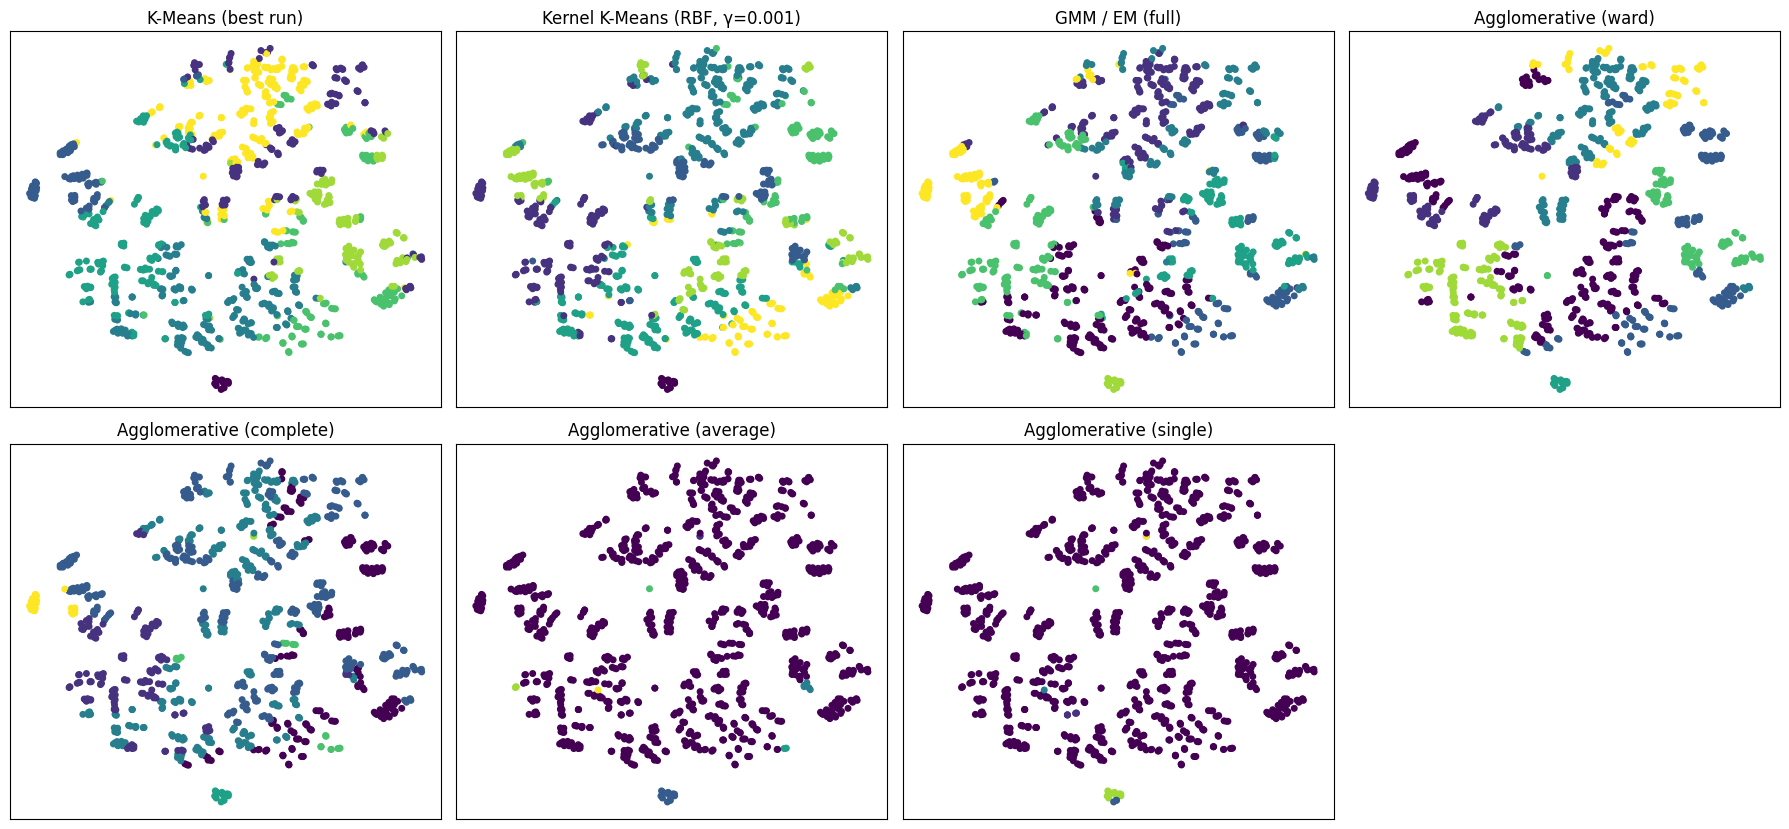

In [443]:
methods = []

# K-Means
if 'labels_kmeans' in globals():
    methods.append(("K-Means (best run)", labels_kmeans))

# Kernel K-Means
if 'kkm_labels' in globals() and 'best_gamma' in globals():
    methods.append((f"Kernel K-Means (RBF, γ={best_gamma})", kkm_labels))
elif 'kkm_labels' in globals():
    methods.append(("Kernel K-Means (RBF)", kkm_labels))

# GMM / EM
if 'label_gmm' in globals():
    methods.append(("GMM / EM (full)", label_gmm))

# Agglomerative
if 'agg_results' in globals():
    for lk in ["ward", "complete", "average", "single"]:
        if lk in agg_results:
            methods.append((f"Agglomerative ({lk})", agg_results[lk]["labels"]))

n_samples = data.shape[0]
perp = int(min(30, max(5, n_samples // 3)))
Z = TSNE(n_components=2, learning_rate='auto', init='pca',perplexity=perp, random_state=42).fit_transform(np.asarray(data))
n = len(methods)
rows = 2
cols = int(np.ceil(n / rows))
fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 4.2*rows))
axes = np.array(axes).reshape(rows, cols)

k_colors = len(np.unique(methods[0][1])) if methods else 10

for i, (title, labels) in enumerate(methods):
    ax = axes.flat[i]
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, s=16, vmin=0, vmax=k_colors-1)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

for j in range(i+1, rows*cols):
    axes.flat[j].axis('off')

plt.tight_layout()
plt.show()

## Task 2: Dimensionality Reduction + Re-Clustering

## 2.1 PCA

In [444]:
# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    data, y_true, test_size=0.3, random_state=42, stratify=y_true
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (756, 77)
Test shape: (324, 77)


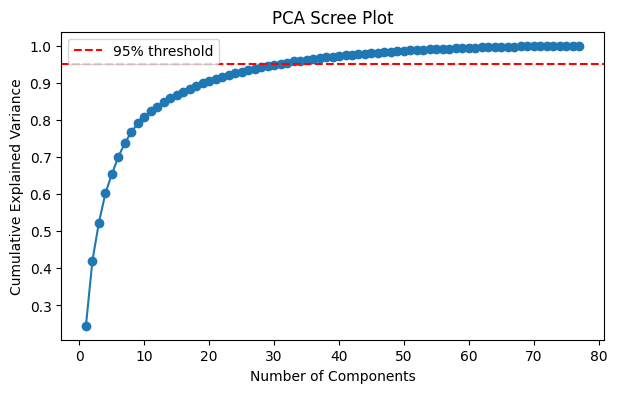

Number of components for >=95% explained variance: 31


In [445]:
# Fit PCA on training data only
pca = PCA(random_state=42)
pca.fit(X_train)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Plot scree plot and cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.legend()
plt.show()

# Choose number of components for >=95% variance
n_pca = np.argmax(cum_var >= 0.95) + 1
print(f"Number of components for >=95% explained variance: {n_pca}")

In [446]:
# Refit PCA keeping only n_pca components
pca = PCA(n_components=n_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Reduced shapes:", X_train_pca.shape, X_test_pca.shape)

Reduced shapes: (756, 31) (324, 31)


## SVD Dimensionality Reduction

TruncatedSVD components for >=95% variance: 31


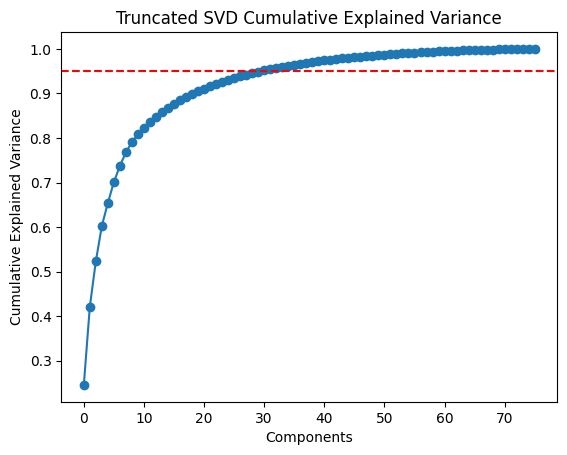

Reduced shapes: (756, 31) (324, 31)


In [447]:
tt = TruncatedSVD(n_components=min(X_train.shape)-1, random_state=42)
tt.fit(X_train)

cum_var = np.cumsum(tt.explained_variance_ratio_)
n_tt = np.argmax(cum_var >= 0.95) + 1
print(f"TruncatedSVD components for >=95% variance: {n_tt}")

plt.plot(cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--')
plt.title("Truncated SVD Cumulative Explained Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

X_train_svd = tt.transform(X_train)[:, :n_tt]
X_test_svd = tt.transform(X_test)[:, :n_tt]
print("Reduced shapes:", X_train_svd.shape, X_test_svd.shape)

As we can see from the results above, PCA and SVD both have cumulative variance curves that are nearly identical. However, there are differences theoretically between the two.

PCA is done to maximize the variance in the data by creating eigenvectors and eigenvalues based on the covariance matrix. 

SVD on the other hand, does not use a covariance matrix. Using the original data matrix, SVD computes the top singular vectors.

Some of the practical differences between the two would be that using the Truncated SVD would be more efficient with larger datasets while PCA may be more useful for data that needs interpretable metrics for explaination of resutls.

## 2.3 Clustering on PCA Space + 2.4 Clustering on SVD Space

In [448]:
def cluster_size_counts(labels):
    u, c = np.unique(labels, return_counts=True)
    return dict(zip(u.tolist(), c.tolist()))

# 1) K-Means
def run_kmeans_multi_seed(X, k, seeds=(0,1,2,3,4)):
    sil_scores, labels_by_seed, sizes_by_seed = [], [], []
    for seed in seeds:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=seed)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)
        labels_by_seed.append(labels)
        sizes_by_seed.append(cluster_size_counts(labels))
        print(f"K-Means | seed {seed:>2} | silhouette = {sil:.4f}")
    avg_sil = float(np.mean(sil_scores))
    best_idx = int(np.argmax(sil_scores))
    best_labels = labels_by_seed[best_idx]
    return {
        "labels": best_labels,
        "silhouette_avg": avg_sil,
        "silhouette_best": sil_scores[best_idx],
        "sizes_best": sizes_by_seed[best_idx],
        "meta": {"best_seed": seeds[best_idx]}
    }

# 2) Kernel K-Means (RBF)
def run_kernel_kmeans_best_gamma(X, k, gammas=(1e-3,1e-2,1e-1,1,10)):
    X_arr = np.asarray(X, dtype=float)
    best_gamma, best_sil, best_labels = None, -np.inf, None

    for g in gammas:
        labels, iters, info = kernel_kmeans(
            X_arr, k, kernel='rbf', kernel_param=g, max_iter=200, tol=1e-3, random_state=42
        )
        s = silhouette_score(X_arr, labels)
        print(f"Kernel K-Means (prof) | gamma={g:<6} | iters={iters:2d} | moved_last={info['moved'][-1]:.4f} | silhouette={s:.4f}")
        if s > best_sil:
            best_gamma, best_sil, best_labels = g, s, labels

    return {"labels": best_labels, "silhouette": best_sil, "meta": {"gamma": best_gamma}}

# 3) GMM
def run_gmm_full(X, k):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
    labels = gmm.fit_predict(X)
    s = silhouette_score(X, labels)
    print(f"GMM | silhouette={s:.4f}")
    return {"labels": labels, "silhouette": s, "meta": {}}

# 4) Agglomerative
def run_agglomerative_all(X, k, linkages=("ward","complete","average","single")):
    out = {}
    for lk in linkages:
        agg = AgglomerativeClustering(n_clusters=k, linkage=lk)
        lab = agg.fit_predict(X)
        s = silhouette_score(X, lab) if len(np.unique(lab)) > 1 else np.nan
        key = f"Agg-{lk}"
        out[key] = {"labels": lab, "silhouette": s, "sizes": cluster_size_counts(lab), "meta": {"linkage": lk}}
        print(f"{key:>12s} | silhouette={s:.4f}")
    return out

# 5) Registry
SPACES = {} 

# 6) Run all methods on X, return table
def run_all_methods_on(X, k, tag=""):
    results = {}

    km_res  = run_kmeans_multi_seed(X, k)
    results["KMeans"] = {"labels": km_res["labels"], "silhouette": km_res["silhouette_avg"], "meta": km_res["meta"]}

    kkm_res = run_kernel_kmeans_best_gamma(X, k)
    results["KernelKMeans"] = {"labels": kkm_res["labels"], "silhouette": kkm_res["silhouette"], "meta": kkm_res["meta"]}

    gmm_res = run_gmm_full(X, k)
    results["GMM"] = {"labels": gmm_res["labels"], "silhouette": gmm_res["silhouette"], "meta": gmm_res["meta"]}

    agg_res = run_agglomerative_all(X, k)
    results.update(agg_res)

    # Summary table
    rows = []
    for name, res in results.items():
        rows.append([f"{tag} :: {name}", res["silhouette"], cluster_size_counts(res["labels"])])
    df = pd.DataFrame(rows, columns=["Method","Silhouette","Cluster sizes"])

    # labels dict
    labels_dict = {name: res["labels"] for name, res in results.items()}
    if tag:
        key = tag.strip().lower().replace("-", "").replace(" ", "")
        globals()[f"res_{key}"] = results
        SPACES[tag] = results

    return results, df, labels_dict

# 7) TSNE grid
def tsne_grid_shared(X, labels_dict, title_prefix=""):
    titles = list(labels_dict.keys())
    Z = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, random_state=42).fit_transform(np.asarray(X))
    m = len(titles)
    rows, cols = 2, int(np.ceil(m/2))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 4.2*rows))
    axes = np.array(axes).reshape(rows, cols)
    max_k = max(len(np.unique(labels_dict[t])) for t in titles)
    for i, name in enumerate(titles):
        ax = axes.flat[i]
        lbls = labels_dict[name]
        ax.scatter(Z[:,0], Z[:,1], c=lbls, s=16, vmin=0, vmax=max_k-1)
        ax.set_title(f"{title_prefix} :: {name}")
        ax.set_xticks([]); ax.set_yticks([])
    for j in range(i+1, rows*cols):
        axes.flat[j].axis('off')
    plt.tight_layout() 
    plt.show()

K-Means | seed  0 | silhouette = 0.1392
K-Means | seed  1 | silhouette = 0.1454
K-Means | seed  2 | silhouette = 0.1449
K-Means | seed  3 | silhouette = 0.1455
K-Means | seed  4 | silhouette = 0.1441
Kernel K-Means (prof) | gamma=0.001  | iters=23 | moved_last=0.0000 | silhouette=0.1372
Kernel K-Means (prof) | gamma=0.01   | iters=19 | moved_last=0.0009 | silhouette=0.0927
Kernel K-Means (prof) | gamma=0.1    | iters=17 | moved_last=0.0000 | silhouette=-0.0840
Kernel K-Means (prof) | gamma=1      | iters= 1 | moved_last=0.0000 | silhouette=-0.0268
Kernel K-Means (prof) | gamma=10     | iters= 1 | moved_last=0.0000 | silhouette=-0.0268
GMM | silhouette=0.1067
    Agg-ward | silhouette=0.1015
Agg-complete | silhouette=0.0769
 Agg-average | silhouette=0.1170
  Agg-single | silhouette=0.0986


,Method,Silhouette,Cluster sizes
0,PCA :: KMeans,0.143823,"{0: 226, 1: 154, 2: 216, 3: 137, 4: 139, 5: 80..."
1,PCA :: KernelKMeans,0.137153,"{0: 173, 1: 151, 2: 150, 3: 124, 4: 149, 5: 11..."
2,PCA :: GMM,0.106695,"{0: 15, 1: 180, 2: 150, 3: 193, 4: 83, 5: 208,..."
3,PCA :: Agg-ward,0.101486,"{0: 198, 1: 161, 2: 166, 3: 113, 4: 96, 5: 15,..."
4,PCA :: Agg-complete,0.076865,"{0: 548, 1: 143, 2: 235, 3: 15, 4: 2, 5: 21, 6..."
5,PCA :: Agg-average,0.116989,"{0: 1040, 1: 10, 2: 2, 3: 15, 4: 1, 5: 3, 6: 6..."
6,PCA :: Agg-single,0.098576,"{0: 15, 1: 1059, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1,..."


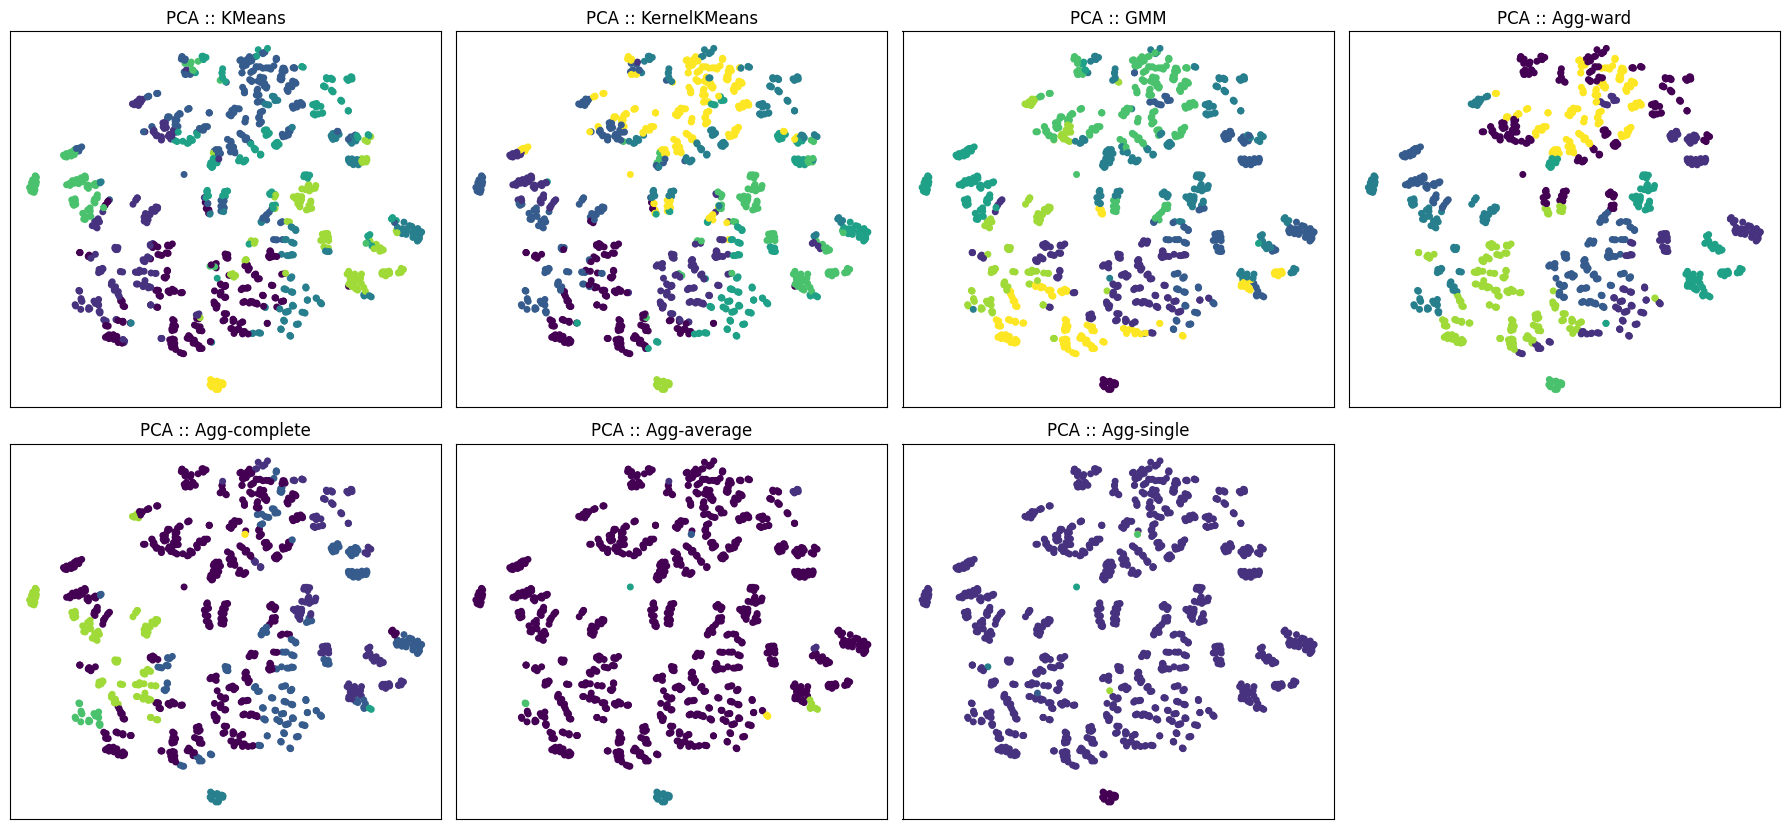

K-Means | seed  0 | silhouette = 0.1390
K-Means | seed  1 | silhouette = 0.1332
K-Means | seed  2 | silhouette = 0.1449
K-Means | seed  3 | silhouette = 0.1455
K-Means | seed  4 | silhouette = 0.1457
Kernel K-Means (prof) | gamma=0.001  | iters=23 | moved_last=0.0000 | silhouette=0.1371
Kernel K-Means (prof) | gamma=0.01   | iters=15 | moved_last=0.0009 | silhouette=0.0918
Kernel K-Means (prof) | gamma=0.1    | iters=17 | moved_last=0.0009 | silhouette=-0.0853
Kernel K-Means (prof) | gamma=1      | iters= 1 | moved_last=0.0000 | silhouette=-0.0268
Kernel K-Means (prof) | gamma=10     | iters= 1 | moved_last=0.0000 | silhouette=-0.0268
GMM | silhouette=0.1032
    Agg-ward | silhouette=0.1015
Agg-complete | silhouette=0.0768
 Agg-average | silhouette=0.1133
  Agg-single | silhouette=0.0989


,Method,Silhouette,Cluster sizes
0,SVD :: KMeans,0.141659,"{0: 142, 1: 160, 2: 227, 3: 15, 4: 77, 5: 208,..."
1,SVD :: KernelKMeans,0.137146,"{0: 173, 1: 151, 2: 150, 3: 124, 4: 149, 5: 11..."
2,SVD :: GMM,0.103175,"{0: 15, 1: 241, 2: 179, 3: 128, 4: 135, 5: 134..."
3,SVD :: Agg-ward,0.101484,"{0: 198, 1: 161, 2: 166, 3: 113, 4: 96, 5: 15,..."
4,SVD :: Agg-complete,0.076844,"{0: 548, 1: 143, 2: 235, 3: 15, 4: 2, 5: 21, 6..."
5,SVD :: Agg-average,0.113298,"{0: 1026, 1: 23, 2: 2, 3: 15, 4: 3, 5: 6, 6: 2..."
6,SVD :: Agg-single,0.098943,"{0: 15, 1: 1059, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1,..."


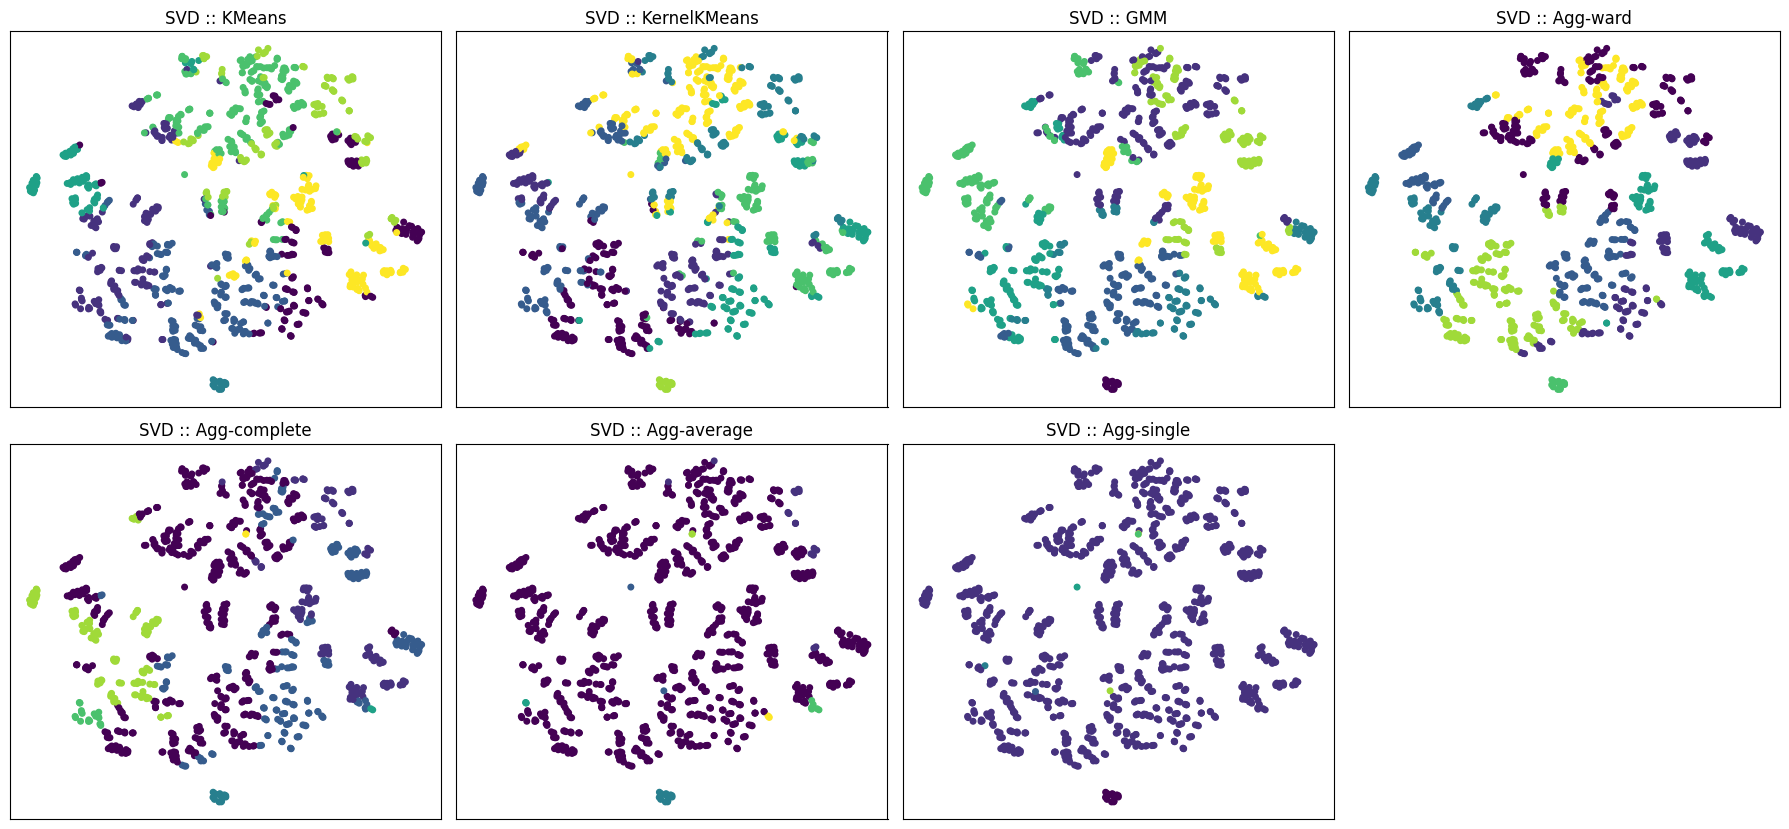

In [449]:
X_pca = np.vstack([X_train_pca, X_test_pca])
X_svd = np.vstack([X_train_svd, X_test_svd])

# Run all 4 methods on PCA space
res_pca, df_pca, labels_pca = run_all_methods_on(X_pca, k, tag="PCA")
display(df_pca)
tsne_grid_shared(X_pca, labels_pca, title_prefix="PCA")

# Run all 4 methods on SVD space
res_svd, df_svd, labels_svd = run_all_methods_on(X_svd, k, tag="SVD")
display(df_svd)
tsne_grid_shared(X_svd, labels_svd, title_prefix="SVD")

## 2.5 KPCA + 2.6 Clustering on KPCA Space

In [450]:
def fit_kpca_best_on_train(X_train, X_test, k, gammas=(1e-3,1e-2,1e-1,1,10), comps=(2,3,5,10,20)):
    best_score = -np.inf
    best_tuple = None
    best_kpca = None

    for g in gammas:
        for n in comps:
            kpca = KernelPCA(n_components=n, kernel="rbf", gamma=g, random_state=42, fit_inverse_transform=False)
            Xtrain_kpca = kpca.fit_transform(X_train)
            kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
            y_kmeans = kmeans.fit_predict(Xtrain_kpca)
            s = silhouette_score(Xtrain_kpca, y_kmeans)
            print(f"KPCA grid | gamma={g:<6} n={n:<2} | proxy silhouette={s:.4f}")
            if s > best_score:
                best_score = s
                best_tuple = (g, n)
                best_kpca = kpca

    print(f"Best KPCA params: gamma={best_tuple[0]}  n_components={best_tuple[1]}  (proxy sil={best_score:.4f})")
    X_train_kpca = best_kpca.fit_transform(X_train)
    X_test_kpca = best_kpca.transform(X_test)
    return best_kpca, X_train_kpca, X_test_kpca, best_tuple

KPCA grid | gamma=0.001  n=2  | proxy silhouette=0.3649
KPCA grid | gamma=0.001  n=3  | proxy silhouette=0.2977
KPCA grid | gamma=0.001  n=5  | proxy silhouette=0.2191
KPCA grid | gamma=0.001  n=10 | proxy silhouette=0.1942
KPCA grid | gamma=0.001  n=20 | proxy silhouette=0.1585
KPCA grid | gamma=0.01   n=2  | proxy silhouette=0.3727
KPCA grid | gamma=0.01   n=3  | proxy silhouette=0.3139
KPCA grid | gamma=0.01   n=5  | proxy silhouette=0.2352
KPCA grid | gamma=0.01   n=10 | proxy silhouette=0.2110
KPCA grid | gamma=0.01   n=20 | proxy silhouette=0.1573
KPCA grid | gamma=0.1    n=2  | proxy silhouette=0.5768
KPCA grid | gamma=0.1    n=3  | proxy silhouette=0.5477
KPCA grid | gamma=0.1    n=5  | proxy silhouette=0.6229
KPCA grid | gamma=0.1    n=10 | proxy silhouette=0.6081
KPCA grid | gamma=0.1    n=20 | proxy silhouette=0.4982
KPCA grid | gamma=1      n=2  | proxy silhouette=0.8994
KPCA grid | gamma=1      n=3  | proxy silhouette=0.9789
KPCA grid | gamma=1      n=5  | proxy silhouette

,Method,Silhouette,Cluster sizes
0,KPCA :: KMeans,0.999382,"{0: 744, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324,..."
1,KPCA :: KernelKMeans,0.993183,"{0: 2, 1: 2, 2: 2, 3: 2, 4: 324, 5: 4, 6: 740,..."
2,KPCA :: GMM,0.997145,"{0: 746, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324}"
3,KPCA :: Agg-ward,0.999382,"{0: 744, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324,..."
4,KPCA :: Agg-complete,0.999382,"{0: 744, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324,..."
5,KPCA :: Agg-average,0.999382,"{0: 744, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324,..."
6,KPCA :: Agg-single,0.999382,"{0: 744, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 324,..."


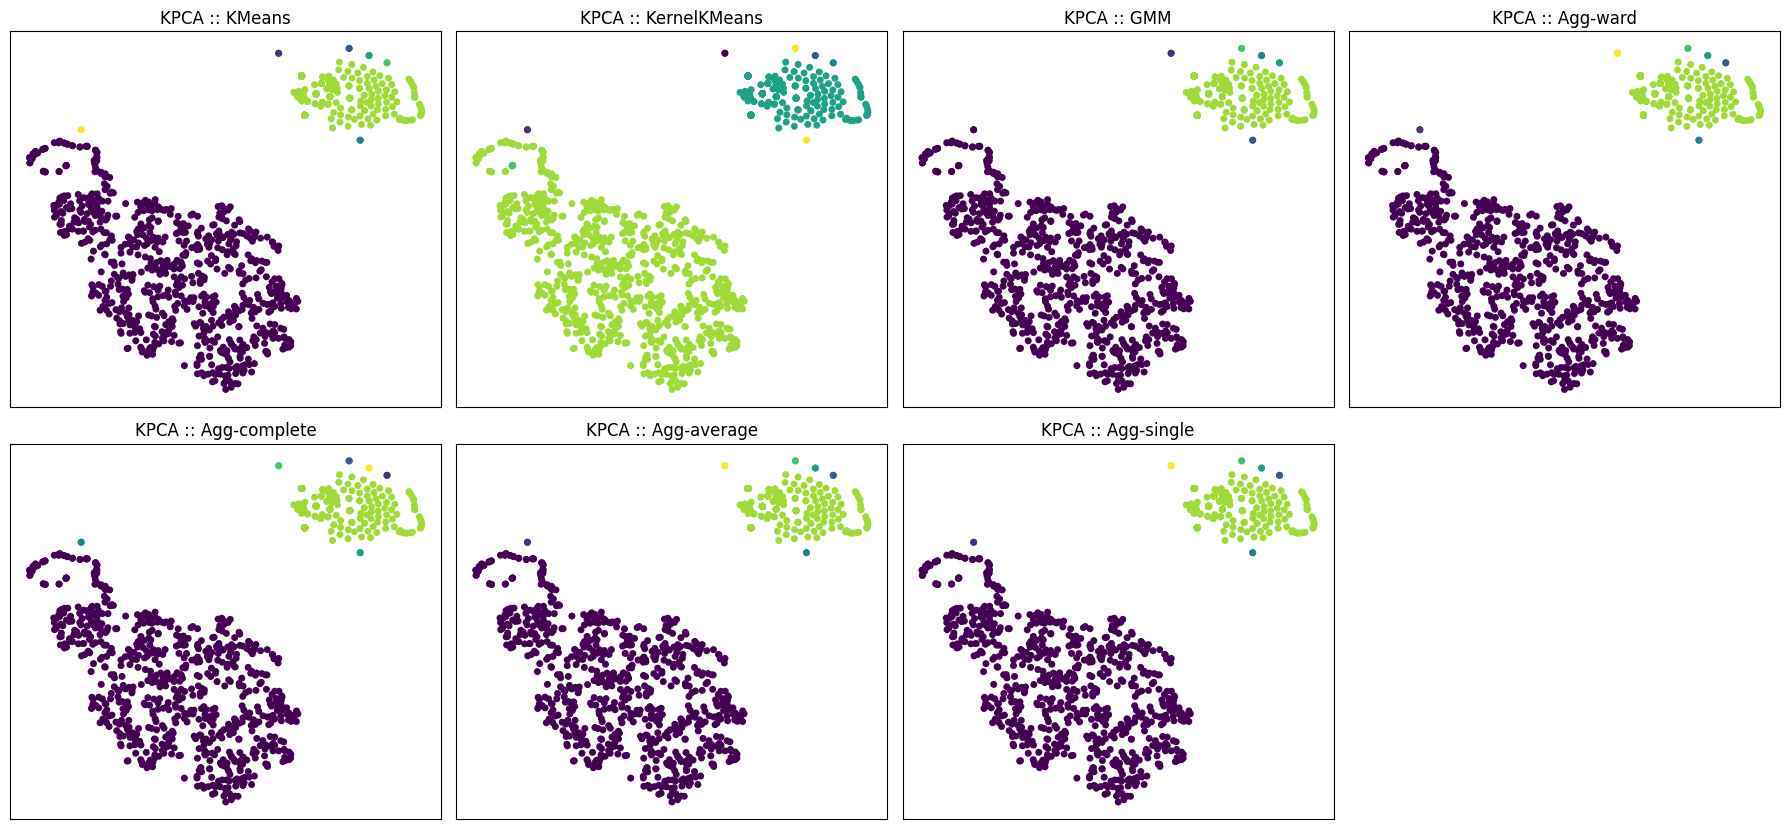

In [451]:
# Fit KPCA on train, then build combined matrix
best_kpca, X_train_kpca, X_test_kpca, best_kpca_params = fit_kpca_best_on_train(X_train, X_test, k)
X_kpca = np.vstack([X_train_kpca, X_test_kpca])

# Run all 4 methods on KPCA space
res_kpca, df_kpca, labels_kpca = run_all_methods_on(X_kpca, k, tag="KPCA")
display(df_kpca)
tsne_grid_shared(X_kpca, labels_kpca, title_prefix="KPCA")

## Discuss Task 2.7

I believe that the PCA and SVD data reduction methods produce more interpretable TSNE visualizations when it comes to using this dataset. The KPCA visualizations group a majority of the datapoints into two large groups, this make it very difficult to interpret the data.

## Task 3: Pseudo-Label Classification (Minimum Distance Classifier)

## 3.1. Best pipeline selection

The unsupervised pipeline that we will be using from tasks 1-2 will be PCA + K-Means.

This pipeline has produced the highest silhouette score when compared to the other methods. The clusters had a good distribution and did not have data points clustered into a single group when referring to the TSNE visualizations. The clusters also seem separated uniformly with minimal overlap. 

The TSNE plots of SVD are nearly identical to the PCA plots. SVD is more efficient on large datasets but PCA provides us with results that can be interpreted or explained more easily.

When looking at the KPCA visualizations, it seems like KPCA improved the cluster separability but made interpreability more difficult.

## 3.2 Train/Test Split

In [452]:
# 1) Split original features and labels
X_train, X_test, y_train, y_test = train_test_split(data, y_true, test_size=0.3, random_state=42, stratify=y_true)

# 2) Fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3) Fit PCA on train only
pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Train PCA shape:", X_train_pca.shape)
print("Test PCA shape:", X_test_pca.shape)

Train PCA shape: (756, 31)
Test PCA shape: (324, 31)


## 3.3 Generate Pseudo-Labels on Train

In [453]:
# K-Means on PCA-reduced training data
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_hat_train = kmeans.fit_predict(X_train_pca)

print("Pseudo-labels (train):", np.unique(y_hat_train, return_counts=True))

# Compute cluster prototypes (centroids in PCA feature space)
prototypes = np.array([
    X_train_pca[y_hat_train == c].mean(axis=0) for c in range(k)
])
print("Prototype matrix shape:", prototypes.shape)

Pseudo-labels (train): (array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([112, 103,  11, 117,  99,  93, 151,  70]))
Prototype matrix shape: (8, 31)


In [454]:
# Assign test samples to nearest prototype
def predict_by_nearest_prototype(X_test_pca, prototypes):
    distances = np.linalg.norm(X_test_pca[:, None, :] - prototypes[None, :, :], axis=2)
    return np.argmin(distances, axis=1)

y_hat_test = predict_by_nearest_prototype(X_test_pca, prototypes)

# Align pseudo-labels using Hungarian algorithm
def align_labels(y_true, y_pred):
    labels_true = np.unique(y_true)
    labels_pred = np.unique(y_pred)
    cost_matrix = np.zeros((len(labels_true), len(labels_pred)))
    for i, t in enumerate(labels_true):
        for j, p in enumerate(labels_pred):
            cost_matrix[i, j] = np.sum((y_true == t) & (y_pred == p)) * -1
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = {labels_pred[c]: labels_true[r] for r, c in zip(row_ind, col_ind)}
    return np.array([mapping[p] for p in y_pred])

# Align predicted labels
y_hat_test_aligned = align_labels(y_hat_train[:len(y_hat_test)], y_hat_test)
test_acc = accuracy_score(y_hat_train[:len(y_hat_test)], y_hat_test_aligned)
print(f"Test accuracy (pseudo-label match): {test_acc:.4f}")

Test accuracy (pseudo-label match): 0.2160


In [455]:
# Encode string labels to ints
true_classes, y_true_ids = np.unique(y_test, return_inverse=True)
pred_clusters, y_pred_ids = np.unique(y_hat_test, return_inverse=True)

# Build cost matrix = -matches
cost = np.zeros((len(true_classes), len(pred_clusters)))
for i in range(len(true_classes)):
    for j in range(len(pred_clusters)):
        cost[i,j] = -np.sum((y_true_ids==i) & (y_pred_ids==j))

r, c = linear_sum_assignment(cost)
mapping = {pred_clusters[cj]: true_classes[ri] for ri, cj in zip(r,c)}

# Apply mapping to predicted clusters
y_hat_test_aligned = np.array([mapping[pred_clusters[j]] for j in y_pred_ids])

In [456]:
# Contingency table (true x predicted cluster BEFORE alignment)
ct = pd.crosstab(pd.Series(y_test, name="True class"), 
                pd.Series([pred_clusters[j] for j in y_pred_ids], 
                        name="Pred cluster")
)
display(ct)

print("Optimal mapping (cluster → class):")
for clus, cls in mapping.items():
    print(f"{clus} → {cls}")

Pred cluster,0,1,2,3,4,5,6,7
True class,,,,,,,,
c-CS-m,6,5,0,13,3,5,11,2
c-CS-s,2,0,0,0,0,0,2,0
c-SC-m,8,7,2,5,6,5,6,6


Optimal mapping (cluster → class):
4 → c-CS-m
7 → c-CS-s
3 → c-SC-m
6 → c-SC-s
0 → t-CS-m
2 → t-CS-s
5 → t-SC-m
1 → t-SC-s


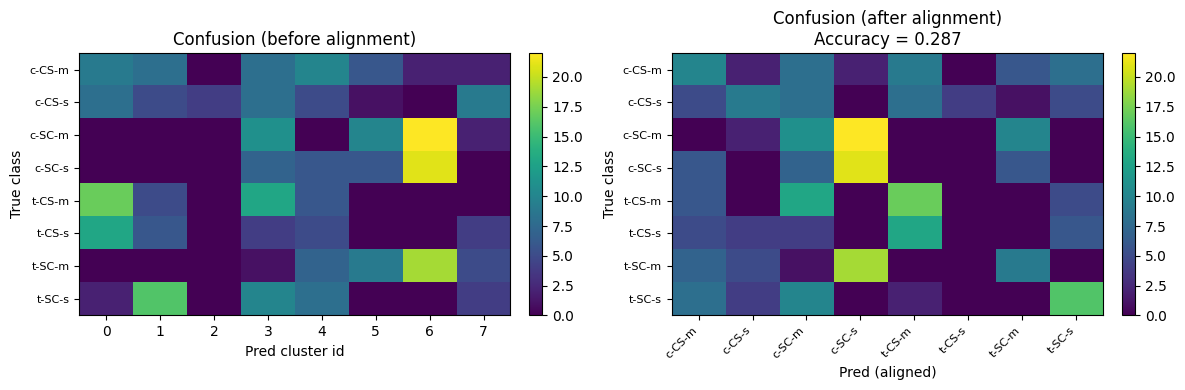

In [457]:
# Encode true classes to ids
true_names, y_true_ids = np.unique(y_test, return_inverse=True)

# BEFORE alignment: map predicted cluster ids to a compact 0..C-1 id space
clus_names, y_pred_ids_raw = np.unique(y_hat_test, return_inverse=True)
cm_raw = confusion_matrix(y_true_ids, y_pred_ids_raw)

# AFTER alignment: convert aligned predicted class names back to ids 0..C-1
name_to_id = {n:i for i,n in enumerate(true_names)}
y_pred_aligned_ids = np.array([name_to_id[n] for n in y_hat_test_aligned])
cm_aligned = confusion_matrix(y_true_ids, y_pred_aligned_ids)

acc_raw = np.max(cm_raw, axis=1).sum() / cm_raw.sum()
acc_aligned = accuracy_score(y_true_ids, y_pred_aligned_ids)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

im = axes[0].imshow(cm_raw, aspect='auto')
axes[0].set_title("Confusion (before alignment)")
axes[0].set_xlabel("Pred cluster id"); axes[0].set_ylabel("True class")
axes[0].set_yticks(range(len(true_names))); axes[0].set_yticklabels(true_names, fontsize=8)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(cm_aligned, aspect='auto')
axes[1].set_title(f"Confusion (after alignment)\nAccuracy = {acc_aligned:.3f}")
axes[1].set_xlabel("Pred (aligned)"); axes[1].set_ylabel("True class")
axes[1].set_yticks(range(len(true_names))); axes[1].set_yticklabels(true_names, fontsize=8)
axes[1].set_xticks(range(len(true_names))); axes[1].set_xticklabels(true_names, rotation=45, ha='right', fontsize=8)
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

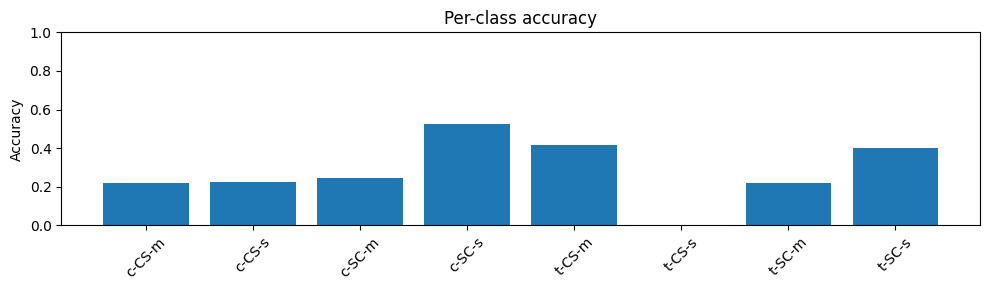

In [458]:
per_class_acc = np.diag(cm_aligned) / cm_aligned.sum(axis=1)
plt.figure(figsize=(10,3))
plt.bar(range(len(true_names)), per_class_acc)
plt.xticks(range(len(true_names)), true_names, rotation=45)
plt.ylim(0, 1); plt.ylabel("Accuracy"); plt.title("Per-class accuracy")
plt.tight_layout(); plt.show()

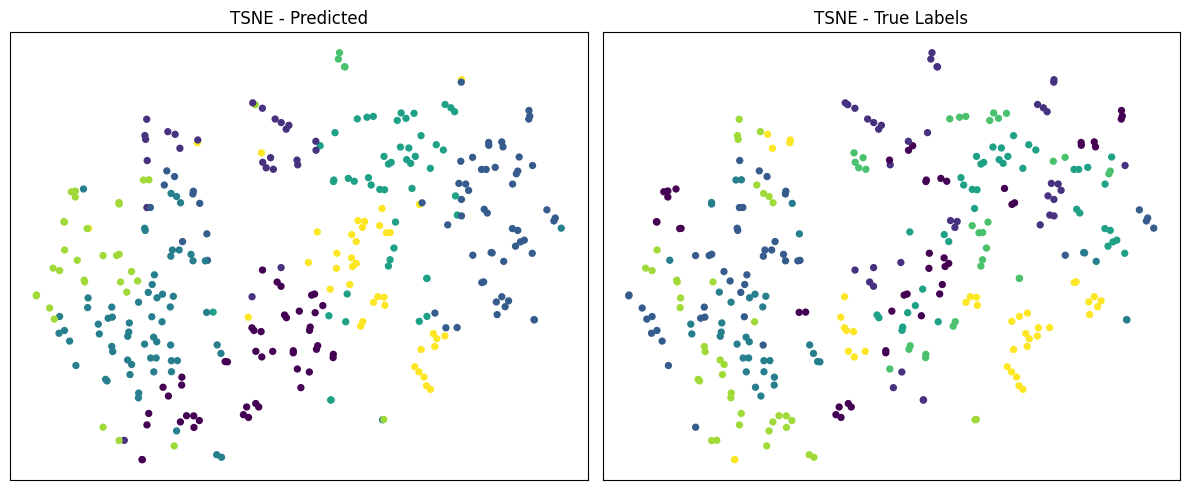

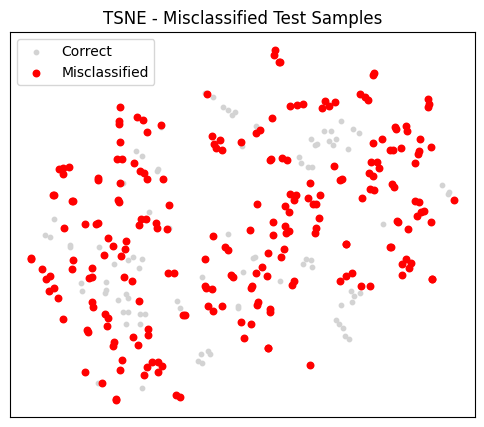

In [459]:
Z_test = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_test_pca)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(Z_test[:,0], Z_test[:,1], c=y_pred_aligned_ids, s=18, vmin=0, vmax=len(true_names)-1)
plt.title("TSNE - Predicted")
plt.xticks([]); plt.yticks([])

plt.subplot(1,2,2)
plt.scatter(Z_test[:,0], Z_test[:,1], c=y_true_ids, s=18, vmin=0, vmax=len(true_names)-1)
plt.title("TSNE - True Labels")
plt.xticks([]); plt.yticks([])

plt.tight_layout(); plt.show()

# Misclassified highlight
mis_idx = np.where(y_pred_aligned_ids != y_true_ids)[0]
plt.figure(figsize=(6,5))
plt.scatter(Z_test[:,0], Z_test[:,1], c="lightgray", s=10, label="Correct")
if mis_idx.size:
    plt.scatter(Z_test[mis_idx,0], Z_test[mis_idx,1], c="red", s=22, label="Misclassified")
plt.legend(); plt.title("TSNE - Misclassified Test Samples")
plt.xticks([]); plt.yticks([]); plt.show()

## Task 4: Bring Back the True Labels — Final Evaluation

## 4.1. Clustering evaluation

In [460]:
# ARI & NMI for all DR spaces
def eval_ari_nmi(spaces_dict, y_true):
    rows = []
    for dr, res in spaces_dict.items():
        for method, info in res.items():
            labels = np.asarray(info["labels"])
            ari = adjusted_rand_score(y_true, labels)
            nmi = normalized_mutual_info_score(y_true, labels)
            rows.append([dr, method, ari, nmi])
    return pd.DataFrame(rows, columns=["DR","Method","ARI","NMI"])

if "SPACES" not in globals() or not SPACES:
    SPACES = {}
    for key, tag in [("res_nodr","No-DR"), ("res_pca","PCA"), ("res_svd","SVD"), ("res_kpca","KPCA")]:
        if key in globals():
            SPACES[tag] = globals()[key]

df_eval_all = eval_ari_nmi(SPACES, y_true)
display(df_eval_all.sort_values(["DR","ARI"], ascending=[True, False]))

# pivot matrices
pivot_ari = df_eval_all.pivot(index="DR", columns="Method", values="ARI")
pivot_nmi = df_eval_all.pivot(index="DR", columns="Method", values="NMI")
display(pivot_ari)
display(pivot_nmi)

,DR,Method,ARI,NMI
16,KPCA,GMM,0.163045,0.394783
14,KPCA,KMeans,0.163016,0.394251
17,KPCA,Agg-ward,0.163016,0.394251
18,KPCA,Agg-complete,0.163016,0.394251
19,KPCA,Agg-average,0.163016,0.394251
20,KPCA,Agg-single,0.163016,0.394251
15,KPCA,KernelKMeans,0.162991,0.391188
1,PCA,KernelKMeans,0.000738,0.012581
6,PCA,Agg-single,0.000076,0.013210
0,PCA,KMeans,0.000005,0.010496


Method,Agg-average,Agg-complete,Agg-single,Agg-ward,GMM,KMeans,KernelKMeans
DR,,,,,,,
KPCA,0.163016,0.163016,0.163016,0.163016,0.163045,0.163016,0.162991
PCA,-0.000144,-0.000641,0.000076,-0.000820,-0.001480,0.000005,0.000738
SVD,0.000126,-0.000641,0.000076,-0.000820,0.001975,-0.000180,0.000738


Method,Agg-average,Agg-complete,Agg-single,Agg-ward,GMM,KMeans,KernelKMeans
DR,,,,,,,
KPCA,0.394251,0.394251,0.394251,0.394251,0.394783,0.394251,0.391188
PCA,0.019575,0.011957,0.013210,0.009481,0.009814,0.010496,0.012581
SVD,0.019093,0.011957,0.013210,0.009481,0.014234,0.010268,0.012581


## 4.2. Classification evaluation


Test accuracy vs y_true (aligned): 0.2870
Mapping (cluster -> class): {np.int64(4): 'c-CS-m', np.int64(7): 'c-CS-s', np.int64(3): 'c-SC-m', np.int64(6): 'c-SC-s', np.int64(0): 't-CS-m', np.int64(2): 't-CS-s', np.int64(5): 't-SC-m', np.int64(1): 't-SC-s'}
Confusion matrix (rows=true, cols=pred):
 [[10  2  8  2  9  0  6  8]
 [ 5  9  8  0  8  4  1  5]
 [ 0  2 11 22  0  0 10  0]
 [ 6  0  7 21  0  0  6  0]
 [ 6  0 13  0 17  0  0  5]
 [ 5  4  4  0 13  0  0  6]
 [ 7  5  1 19  0  0  9  0]
 [ 8  4 10  0  2  0  0 16]]

Classification report (aligned):
              precision    recall  f1-score   support

      c-CS-m       0.21      0.22      0.22        45
      c-CS-s       0.35      0.23      0.27        40
      c-SC-m       0.18      0.24      0.21        45
      c-SC-s       0.33      0.53      0.40        40
      t-CS-m       0.35      0.41      0.38        41
      t-CS-s       0.00      0.00      0.00        32
      t-SC-m       0.28      0.22      0.25        41
      t-SC-s       

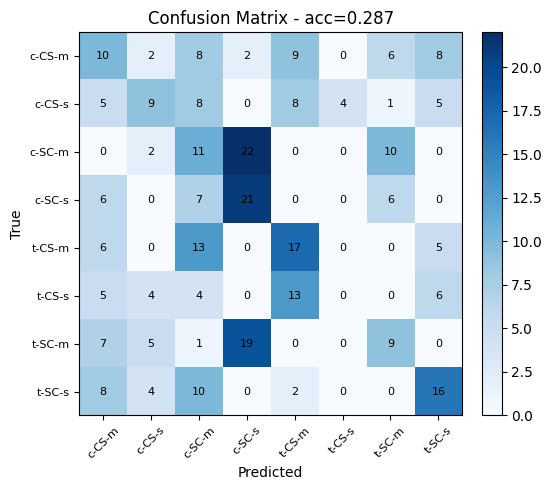

In [461]:
def hungarian_accuracy(y_true, y_pred_clusters):
    # Encode true and predicted into compact ID spaces (0..K-1)
    true_names, y_true_ids = np.unique(y_true, return_inverse=True)
    pred_names, y_pred_ids = np.unique(y_pred_clusters, return_inverse=True)
    
    # Build contingency matrix: shape [n_true_classes, n_pred_clusters]
    M = contingency_matrix(y_true_ids, y_pred_ids, sparse=False)
    
    # Hungarian alignment on NEGATIVE counts (maximize matches)
    cost = -M
    r, c = linear_sum_assignment(cost)
    
    # Map predicted cluster → true class
    mapping = {pred_names[cj]: true_names[ri] for ri, cj in zip(r, c)}
    
    # Apply mapping to predicted clusters
    y_pred_aligned = np.array([mapping[p] for p in y_pred_clusters])
    
    # Compute metrics
    acc = accuracy_score(y_true, y_pred_aligned)
    cm  = confusion_matrix(y_true, y_pred_aligned, labels=true_names)
    
    return acc, cm, true_names, mapping, y_pred_aligned

acc, cm, class_order, mapping, y_pred_aligned = hungarian_accuracy(y_test, y_hat_test)
print(f"Test accuracy vs y_true (aligned): {acc:.4f}")
print("Mapping (cluster -> class):", mapping)
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("\nClassification report (aligned):")
print(classification_report(y_test, y_pred_aligned, target_names=class_order, zero_division=0))

# plot confusion matrix
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - acc={acc:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(class_order))); ax.set_xticklabels(class_order, rotation=45, fontsize=8)
    ax.set_yticks(range(len(class_order))); ax.set_yticklabels(class_order, fontsize=8)
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Confusion plot skipped:", e)

## 4.3. Comprehensive Method Comparison

In [ ]:
# Compare methods & best combos
# Performance matrices:
pivot_ari = df_eval_all.pivot(index="DR", columns="Method", values="ARI")
pivot_nmi = df_eval_all.pivot(index="DR", columns="Method", values="NMI")
display(pivot_ari); display(pivot_nmi)

# Best performing combinations per DR by ARI/NMI
best_by_dr_ari = df_eval_all.loc[df_eval_all.groupby("DR")["ARI"].idxmax()].reset_index(drop=True)
best_by_dr_nmi = df_eval_all.loc[df_eval_all.groupby("DR")["NMI"].idxmax()].reset_index(drop=True)
print("\nBest by ARI per DR:\n", best_by_dr_ari)
print("\nBest by NMI per DR:\n", best_by_dr_nmi)

rng = np.random.default_rng(42)

def bootstrap_ci_metric(y_true, labels, metric_fn, B=300):
    y_true = np.asarray(y_true); labels = np.asarray(labels); n = len(y_true)
    vals = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        vals.append(metric_fn(y_true[idx], labels[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(np.mean(vals)), float(lo), float(hi)

y_true_ids_all = np.unique(y_true, return_inverse=True)[1]

ci_rows = []
for _, row in best_by_dr_ari.iterrows():
    dr, method = row["DR"], row["Method"]
    labels = np.asarray(SPACES[dr][method]["labels"])
    m, lo, hi = bootstrap_ci_metric(y_true_ids_all, labels, adjusted_rand_score, B=300)
    ci_rows.append([dr, method, "ARI", m, lo, hi])

for _, row in best_by_dr_nmi.iterrows():
    dr, method = row["DR"], row["Method"]
    labels = np.asarray(SPACES[dr][method]["labels"])
    m, lo, hi = bootstrap_ci_metric(y_true_ids_all, labels, normalized_mutual_info_score, B=300)
    ci_rows.append([dr, method, "NMI", m, lo, hi])

df_ci = pd.DataFrame(ci_rows, columns=["DR","Method","Metric","Mean","CI_low","CI_high"])
print("\nBootstrap 95% CIs for winners:\n")
display(df_ci)

Method,Agg-average,Agg-complete,Agg-single,Agg-ward,GMM,KMeans,KernelKMeans
DR,,,,,,,
KPCA,0.163016,0.163016,0.163016,0.163016,0.163045,0.163016,0.162991
PCA,-0.000144,-0.000641,0.000076,-0.000820,-0.001480,0.000005,0.000738
SVD,0.000126,-0.000641,0.000076,-0.000820,0.001975,-0.000180,0.000738


Method,Agg-average,Agg-complete,Agg-single,Agg-ward,GMM,KMeans,KernelKMeans
DR,,,,,,,
KPCA,0.394251,0.394251,0.394251,0.394251,0.394783,0.394251,0.391188
PCA,0.019575,0.011957,0.013210,0.009481,0.009814,0.010496,0.012581
SVD,0.019093,0.011957,0.013210,0.009481,0.014234,0.010268,0.012581



Best by ARI per DR:
      DR        Method       ARI       NMI
0  KPCA           GMM  0.163045  0.394783
1   PCA  KernelKMeans  0.000738  0.012581
2   SVD           GMM  0.001975  0.014234

Best by NMI per DR:
      DR       Method       ARI       NMI
0  KPCA          GMM  0.163045  0.394783
1   PCA  Agg-average -0.000144  0.019575
2   SVD  Agg-average  0.000126  0.019093

Bootstrap 95% CIs for winners:



,DR,Method,Metric,Mean,CI_low,CI_high
0,KPCA,GMM,ARI,0.164116,0.149646,0.178678
1,PCA,KernelKMeans,ARI,0.006866,0.002160,0.012063
2,SVD,GMM,ARI,0.008057,0.003410,0.013538
3,KPCA,GMM,NMI,0.396766,0.380828,0.412793
4,PCA,Agg-average,NMI,0.027478,0.018609,0.036519
5,SVD,Agg-average,NMI,0.028761,0.018811,0.038941


## Discussion

Based on the ARI and NMI results, Kernel PCA and GMM acheived the highest alignment with the ground truth. They are higher than other pipelines used on this dataset, however, the Kernel PCA TSNE visualizations showed one large cluster which suggests that there are some issues with using the non-linear kernel.

Overall the PCA and SVD dimensionality reduction methods resulted in lower numerical scores but had data that was more uniformly distributed with clusters that are more interpretable. 


PCA and SVD can bring improvements to methods such as K-Means, however, they can also have a negative impact on performance when the data structures are non-linear.
KPCA can be useful when we need to map the data to another space so that we can better interpret non-linear data. KPCA can also hurt performance depending on the data such as what we have seen here with the large clustering of the majority of the data which leads to reduced interpretability.

PCA and SVD performance was nearly identical. The RBF kernel was very sensitive to changes in the gamma values.

Based on the TSNE visualizations, the KPCA plots showed the clearest cluster separation. The maojrity of the data was separated into two large clusters with no overlap. However, this greatly reduces the interpretability of the dataset when compared to PCA and SVD. PCA + K-Means provided the most interpretable clustering while having a lower ARI and MMI score than KPCA. 